Pontificia Universidad Católica de Chile <br>
Facultad de Matemática <br>
Departamento de Estadística <br>
EYP230I - Análisis de Regresión

---
<center>
    <h2> Proyecto EYP230I: USGS Earthquakes</h2>
</center>

---

In [17]:
# Librerías
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns


## Índice

- [0 Setup](##0-setup-inicial)
- [1 Contexto y pregunta](##1-contexto-y-pregunta)
- [2 Comprensión datos](##2-comprensión-datos)
- [3 Limpieza y nulos](##3-limpieza-y-nulos)
- [4 EDA orientado a pregunta](##4-eda-orientado-a-pregunta)
- [5 Modelos candidatos](##5-modelos-candidatos)
- [6 Conclusión preliminar](##5-conclusion-preliminar)



## 0. Fuente dataset y Setup inicial

### Procedencia de los datos

Los datos provienen del catálogo oficial de eventos sísmicos del U.S. Geological Survey (USGS), obtenidos mediante la Earthquake Catalog API, que registra eventos sísmicos detectados por redes de monitoreo internacionales. 
Dicha API implementa la especificación de servicios web de la International Federation of Digital Seismograph Networks (FDSN). Esta especificación define interfaces estandarizadas para consultar eventos sísmicos, series temporales y metadatos asociados, permitiendo interoperabilidad y reproducibilidad entre distintos centros sismológicos. La utilización de un estándar FDSN fortalece la trazabilidad y consistencia del proceso de extracción de datos (CITAR API).


La unidad de observación corresponde a un evento sísmico individual registrado durante 2024 con magnitud al menos 4. En este marco, el USGS nos termina proporcionando además variables relacionadas con localización, profundidad, calidad de medición del sismo.

### Descarga y preparación dataset

Este notebook descarga el catálogo oficial de eventos sísmicos del **USGS Earthquake Catalog** para el año 2024, filtrando eventos con **magnitud al menos 4**, y deja una base lista para un proyecto de **Análisis de Regresión** donde la variable dependiente numérica es:

\[
Y = 	magnitud de un sismo
\]

La API usada es:

`https://earthquake.usgs.gov/fdsnws/event/1/query`

La documentación indica que el método `query` permite consultar eventos usando parámetros como `format`, `starttime`, `endtime`, `minmagnitude`, `limit`, `offset`, `orderby`, entre otros.

Para los datos, necesitamos:

- eventos del año **2024**;
- magnitud mínima **4**;
- variable respuesta: **magnitud**;
- variables disponibles: fecha/hora, latitud, longitud, profundidad, tipo de magnitud, número de estaciones, brecha azimutal, distancia mínima, RMS, red de reporte y lugar.

En la API, esto se traduce en:

- `starttime=2024-01-01`
- `endtime=2025-01-01`
- `minmagnitude=4`
- `format=csv`

Uso `endtime=2025-01-01` para incluir todo 2024 hasta el 31 de diciembre.

In [6]:
# Descarga del dataset 
url_api = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=csv"
    "&starttime=2024-01-01"
    "&endtime=2025-01-01"
    "&minmagnitude=4"
)

# Descargar datos desde la API
df_sismos = pd.read_csv(url_api)

# Guardar en la ruta local (misma carpeta del notebook)
df_sismos.to_csv("sismos_2024_mag4.csv", index=False)
print("Archivo guardado como 'sismos_2024_mag4.csv'")

Archivo guardado como 'sismos_2024_mag4.csv'


## 1. Contexto y pregunta del proyecto

- ¿En qué medida las características físicas del sismo (profundidad) y las condiciones instrumentales de captura (número de estaciones, error residual rms, brecha azimutal) se asocian con la magnitud final reportada por el USGS durante el 2024, controlando por el tipo de escala de medición empleada?

### 1.1 Motivación del estudio



Comprender los factores físicos, estructurales e intrumentales detras de la magnitud de un evento sísmico es de vital importancia tanto de una perspectiva geofísica como socioambiental.

Los sismos representan una de las amenazas natuales de mayor riesgo destructivo... (agregar justificaión por asignación recursos por subestimar daño o alarma innecsaria por sobrestimar daños)

### 1.2 Objetivo a seguir en el estudio



El presente eddstudio adopta un enfoque descriptivo o explicativo. El objetivo central es cuantificar y comprendeer en qué medida las variables físicas de un eveto sísmico (profundidad) y variables instrumentales de control (numéro estaciones, gap, etc), se asocian con la magnitud final reporta por el USGS, controlando por el tipo de escala.

Se opta principalmente por este enfoque descriptivo sobre uno predictivo, dado que varias variables disponibles en el catálogo corresponden a características simultaneas o poseterior a la identificación del evento. De modo que el interes principal no es contruir un modelo de predicción en tiempo real, sino el estudio de posibles asociaciones estadísticas, incertidumbre, y el papel de fcatores físicos y de medición.

### 1.3 Consideraciones éticas 

El presente análisis se fundamenta en información de naturaleza estrictamente geofísica e instrumental, por lo que no involucra sujetos humanos, variables sociodemográficas ni información médicamente sensible. 

De todos modos, como el estudio esta basado en una API pública, de libre acceso, provista por una entidad gubernamental (USGS), el proyecto respeta íntegramente criterios éticos como la transparencia científica, garantizando su futura reproducibilidad del código empleado.

## 2. Comprensión datos

In [7]:
# Información preliminar de los datos para comprender mejor el dataset
print(f"Dimensiones del dataset: {df_sismos.shape[0]} filas y {df_sismos.shape[1]} columnas.\n")

print("--- Información de tipos de datos de la API ---")
df_sismos.info()

print("\n--- Primeros 5 registros ---")
df_sismos.head()

print("\n--- Resumen estadístico numérico preliminar ---")
df_sismos.describe()

Dimensiones del dataset: 14176 filas y 22 columnas.

--- Información de tipos de datos de la API ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14176 entries, 0 to 14175
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             14176 non-null  object 
 1   latitude         14176 non-null  float64
 2   longitude        14176 non-null  float64
 3   depth            14176 non-null  float64
 4   mag              14176 non-null  float64
 5   magType          14176 non-null  object 
 6   nst              14125 non-null  float64
 7   gap              14124 non-null  float64
 8   dmin             14124 non-null  float64
 9   rms              14175 non-null  float64
 10  net              14176 non-null  object 
 11  id               14176 non-null  object 
 12  updated          14176 non-null  object 
 13  place            14176 non-null  object 
 14  type             14176 non-null  object 
 15  hor

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,14176.000000,14176.000000,14176.000000,14176.000000,14125.000000,14124.000000,14124.000000,14175.000000,14116.000000,14176.000000,14055.000000,14113.000000
mean,3.451397,33.277429,92.462849,4.491348,49.792779,106.742053,3.654399,0.706782,8.743717,4.930400,0.117796,36.782895
std,28.565349,122.858037,142.314471,0.376016,42.680362,45.778472,4.843781,0.220588,3.509284,3.467842,0.053136,53.263570
min,-65.300900,-179.999100,-0.070000,4.000000,7.000000,10.000000,0.000000,0.000000,0.090000,0.090000,0.000000,0.000000
25%,-18.558650,-73.129150,10.000000,4.200000,22.000000,73.000000,1.125000,0.550000,6.280000,1.903000,0.077000,12.000000
50%,0.968600,91.571050,34.621500,4.400000,35.000000,102.000000,2.284500,0.690000,8.540000,4.478000,0.111000,20.000000
75%,25.569225,137.337000,109.492000,4.600000,62.000000,135.000000,4.221000,0.840000,11.020000,7.296250,0.151000,39.000000
max,86.605300,179.998400,671.043000,7.500000,619.000000,343.000000,62.558000,1.740000,32.320000,31.960000,0.526000,954.000000


### Diccionario de variables



| Variable | Tipo de variable | Descripción |
|---|---:|---|
| `mag` | Numérica continua | Magnitud del evento sísmico, utilizada como **variable dependiente** del análisis. |
| `time` | Temporal (`datetime`) | Fecha y hora exacta en que ocurrió el evento sísmico. Puede utilizarse para derivar variables temporales (mes, hora, estacionalidad). |
| `latitude` | Numérica continua | Coordenada geográfica de latitud del epicentro del evento sísmico. |
| `longitude` | Numérica continua | Coordenada geográfica de longitud del epicentro del evento sísmico. |
| `depth` | Numérica continua | Profundidad del sismo, medida en kilómetros desde la superficie terrestre hasta el foco del evento. |
| `magType` | Categórica nominal | Método o escala utilizada para calcular la magnitud del evento (ejemplo: `mb`, `mw`, `ml`, `mww`). |
| `nst` | Numérica discreta | Número de estaciones sísmicas que detectaron y contribuyeron a la localización del evento. |
| `gap` | Numérica continua | Mayor ángulo o “brecha” (en grados) sin cobertura de estaciones alrededor del epicentro. Valores menores indican mejor precisión espacial del registro. |
| `dmin` | Numérica continua | Distancia entre el epicentro y la estación sísmica más cercana. Se utiliza como indicador de calidad del registro. |
| `rms` | Numérica continua | Error residual (en segundos) asociado al ajuste de los tiempos de viaje de las ondas sísmicas. Valores menores indican una localización más consistente con los datos observados. |
| `net` | Categórica nominal | Red sísmica principal que reporta el evento (ejemplo: `us` para USGS). |
| `id` | Identificador (texto) | Identificador único asignado a cada evento sísmico dentro de la base de datos. |
| `updated` | Temporal (`datetime`) | Fecha y hora de la última actualización o modificación del registro del evento. |
| `place` | Texto / categórica nominal | Descripción textual aproximada del lugar donde ocurrió el evento (ejemplo: `"10 km South of Santiago"`). |
| `type` | Categórica nominal | Tipo de evento registrado (ejemplo: `earthquake`, explosión de cantera u otros eventos geológicos). |
| `horizontalError` | Numérica continua | Margen estimado de incertidumbre en la localización horizontal (latitud/longitud) del epicentro. |
| `depthError` | Numérica continua | Margen estimado de incertidumbre asociado a la medición de profundidad del evento. |
| `magError` | Numérica continua | Margen de incertidumbre asociado a la estimación de la magnitud del sismo. |
| `magNst` | Numérica discreta | Número de estaciones utilizadas específicamente para estimar la magnitud del evento. |
| `status` | Categórica nominal | Estado del reporte: automático (`automatic`) o revisado por un sismólogo (`reviewed`). |
| `locationSource` | Categórica nominal | Red o sistema responsable de calcular la ubicación geográfica del evento. |
| `magSource` | Categórica nominal | Red o sistema responsable de calcular la magnitud del evento. |


A partir del resumen estadístico de las variables, se destacan los siguientes comportamientos en la muestra inicial ($n \approx 14.000$):

- Magnitud de los eventos (mag): El dataset abarca sismos con magnitud que van desde nuestro punto de corte (4.0) hasta un máximo de 7.5. La media se situa en 7.5. Un punto importante a destacar es que el 75% de los datos contemplan magnitudes menores o iguales a 4.6, lo que es lógico ya que suelen haber más sismos de mediana magnitud que grandes terremotos. 


- Profundidad sismo (depth): Se observa una dispersión drástica en la profundidad de los sismos (d estándar = 142.3 km). Los registros varían desde eventos extremadamente superficiales (cercanos al 0) hasta sismos ultra-profundos que alcanzan los 671 km. Una evidencia adicional a esta dispersión entre los datos podemos encontrar al comprar la media (92.46 km) y la mediana (34.62 km), lo que sugiera una cola en la distribución (a la derecha), aunque también podría ser producto de la construcción del dataset (ya que solo toma sismos con mag > 4).

- Variables Instrumentales de Control: El número de estaciones receptoras (nst) presenta un promedio de casi 50 estaciones por evento, pero con un máximo extremo de 619, lo que sugiere una heterogeneidad en la detección global de los sismos en el dataset. Por otro lado, la brecha azimutal (gap) promedia 106.7°, lo que sugiere una cobertura razonable para la mayoría de eventos, teniendo en cuenta que el máximo valor se registra en 343°.

## 3. Limpieza y filtrado inicial

### 3.1 Valores nulos

In [8]:
# Analizamos presencia de datos nulos en general
print("\n--- Conteo de Datos Faltantes por Variables ---")
print(df_sismos.isnull().sum())


--- Conteo de Datos Faltantes por Variables ---
time                 0
latitude             0
longitude            0
depth                0
mag                  0
magType              0
nst                 51
gap                 52
dmin                52
rms                  1
net                  0
id                   0
updated              0
place                0
type                 0
horizontalError     60
depthError           0
magError           121
magNst              63
status               0
locationSource       0
magSource            0
dtype: int64


Tenemos una seria de 6 columnas que presentan data nula. Luego, como muchas de estas corresponden a metadatos del dataset (no son realmente variables estadísticas que nos puede servir en el análisis de regresión), no las usaremos en el modelo. Dentro de estas, tenemos id (código identificador), time y update (temporales que no tendremos en cuenta para el modelo debido a la característica de la pregunta), url, detail, alert, location_source, mag_source. (enlaces a API, descriptivos, metadatos).

De este modo, al analizar las variables de interes para el modelo, debido a la baja presencia de datos nulos (menos del 0.5%), podemos simplemente hacer una dropna() para lidiar con ellos. Luego, como solo consideramos ciertas variables para el modelo, este método nos hacer desechar lo menos posible.


In [9]:
# Analizamos solo variables candidatas a un modelo de regresión (numéricaso o similares)
variables_interes = ['mag', 'depth', 'latitude', 'longitude', 'nst', 'gap', 'dmin', 'rms', 'magType']
df_analisis = df_sismos[variables_interes].copy()
print("\n--- Conteo de Datos Faltantes por Variables de Interés ---")
print(df_analisis.isnull().sum())



--- Conteo de Datos Faltantes por Variables de Interés ---
mag           0
depth         0
latitude      0
longitude     0
nst          51
gap          52
dmin         52
rms           1
magType       0
dtype: int64


In [10]:
# Eliminamos registros con data nula
df_analisis = df_analisis.dropna()
print(f"\nTamaño de la muestra analizada inicial (n): {df_sismos.shape[0]} observaciones.")
print(f"\nTamaño de la muestra analizada final (n): {df_analisis.shape[0]} observaciones.")


Tamaño de la muestra analizada inicial (n): 14176 observaciones.

Tamaño de la muestra analizada final (n): 14124 observaciones.


### 3.2 Filtrado categórico

In [11]:
# Análisis y depuración de la úncia variable categórica 'magType'
print("\n--- Frecuencia de Tipos de Magnitud (magType) ---")
print(df_analisis['magType'].value_counts())


--- Frecuencia de Tipos de Magnitud (magType) ---
magType
mb     12205
mww     1161
mwr      600
ml        58
mw        57
md        38
mwb        4
mh         1
Name: count, dtype: int64


Como tenemos categorías poco representativas (como mwb o mh) nos quedaremos solo con tipos de magnitud que superen >30 en su frecuencia para prevenir inestabilidad en la regresión MCO (generación de columnas prácticamente vacías en la matriz de diseño, y por ende, una inflación artificial de los errores).

In [12]:
# Conservamos solo los tipos de magnitud que tengan una representación suficiente (> 10)
frecuencias = df_analisis['magType'].value_counts()
categorias_validas = frecuencias[frecuencias >= 30].index
df_analisis = df_analisis[df_analisis['magType'].isin(categorias_validas)]
print(f"\nTamaño de la muestra tras depurar 'magType': {df_analisis.shape[0]} observaciones.")


Tamaño de la muestra tras depurar 'magType': 14119 observaciones.


## 4. EDA y codificaciones

### 4.1 Distribución variable objetivo

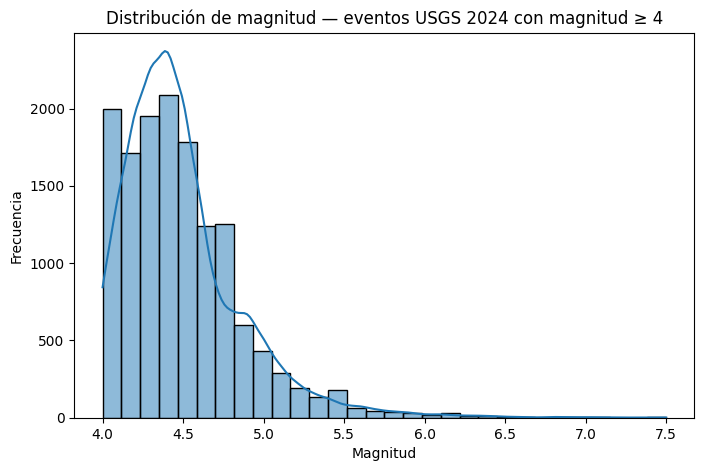

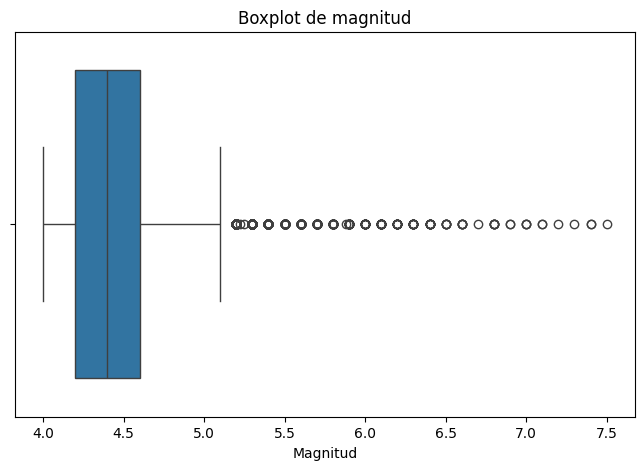

In [13]:
# Exploración básica de la variable respuesta
plt.figure(figsize=(8, 5))
sns.histplot(df_analisis["mag"], bins=30, kde=True)
plt.title("Distribución de magnitud — eventos USGS 2024 con magnitud ≥ 4")
plt.xlabel("Magnitud")
plt.ylabel("Frecuencia")
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(x=df_analisis["mag"])
plt.title("Boxplot de magnitud")
plt.xlabel("Magnitud")
plt.show()

### 4.2 Relación con variables predictoras

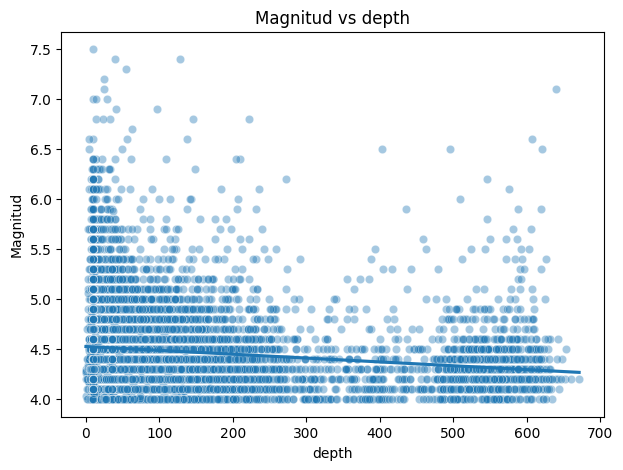

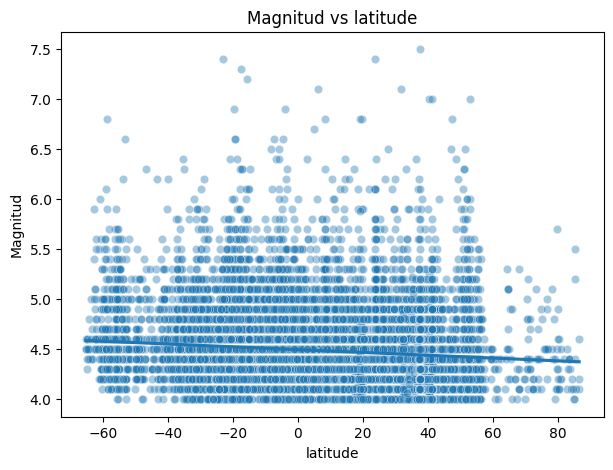

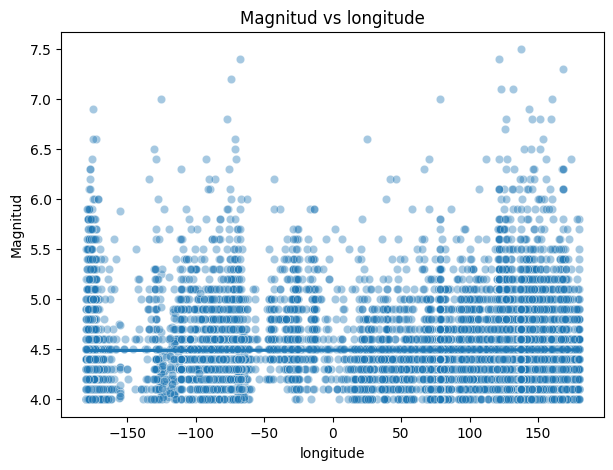

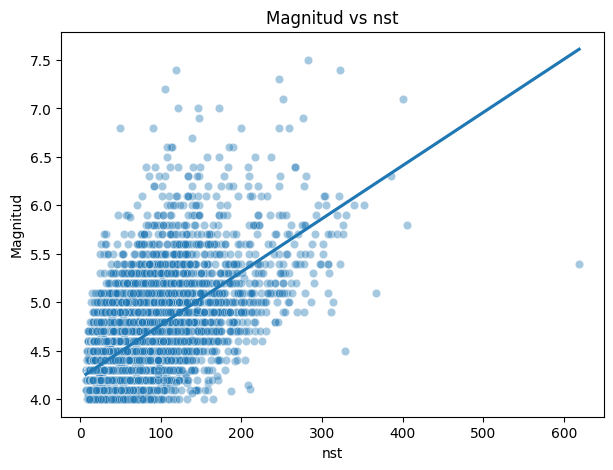

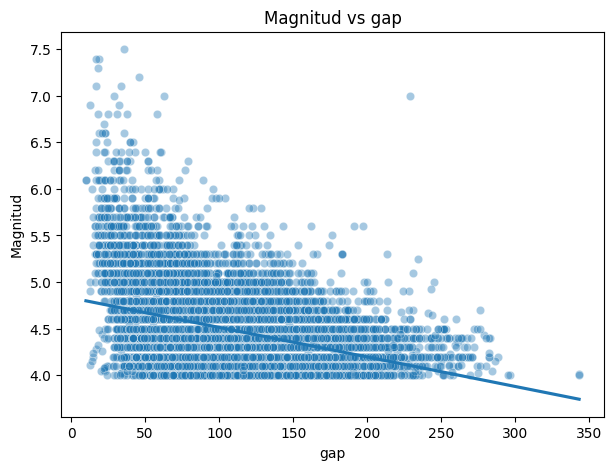

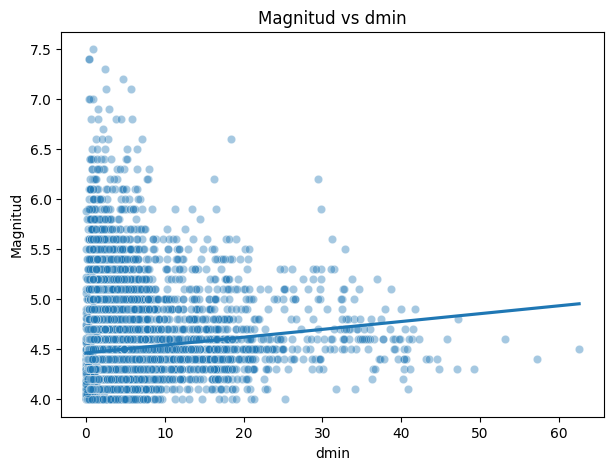

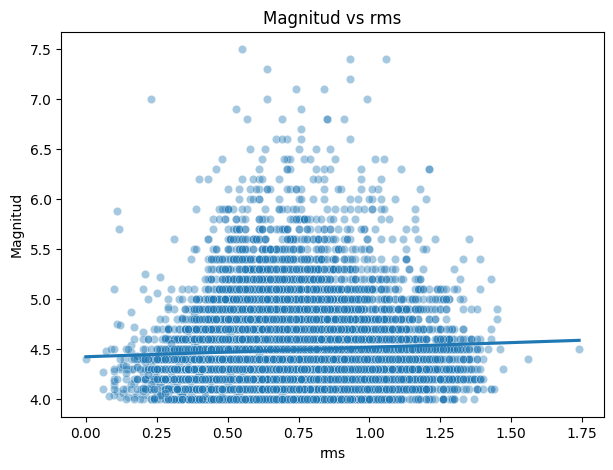

In [14]:
candidate_numeric = ["depth", "latitude", "longitude", "nst", "gap", "dmin", "rms"]

for col in candidate_numeric:
    if col in df_analisis.columns:
        temp = df_analisis[["mag", col]].dropna()
        if temp.shape[0] > 0:
            plt.figure(figsize=(7, 5))
            sns.scatterplot(data=temp, x=col, y="mag", alpha=0.4)
            sns.regplot(data=temp, x=col, y="mag", scatter=False, ci=None)
            plt.title(f"Magnitud vs {col}")
            plt.xlabel(col)
            plt.ylabel("Magnitud")
            plt.show()

### 4.3 Distribución variable categórica

In [15]:
# box plot y codificacon onehot

### 4.3 Matriz de correlación

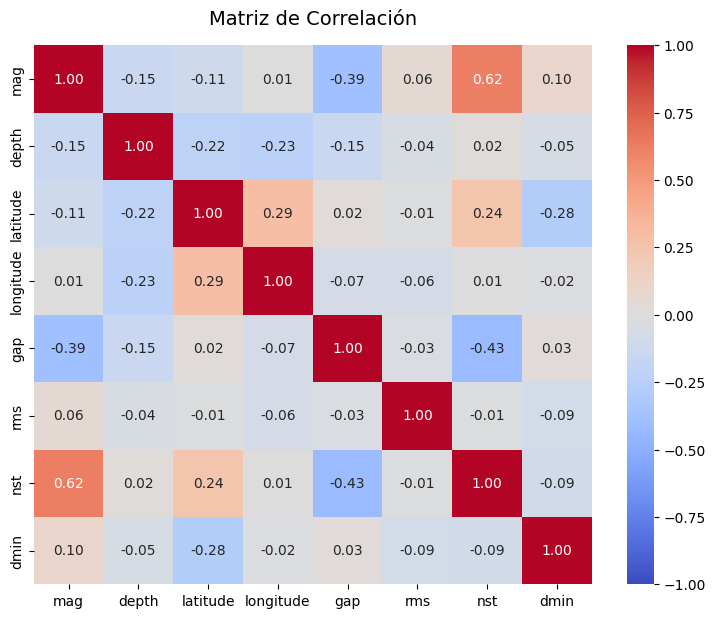

In [16]:
variables_num = ['mag', 'depth', 'latitude', 'longitude', 'gap', 'rms', 'nst', 'dmin']

plt.figure(figsize=(9, 7))
sns.heatmap(df_analisis[variables_num].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación', fontsize=14, pad=15)
plt.savefig('eda_matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.4 Análsis de VIF

Análisis previo al modelamiento para identificar variables que duplican información.

## 5. Modelación propuesta

### 5.1 Modelos lineales candidatos

### 5.2 Diagnósticos previstos

## 6. Conclusión preliminar

Identificar relaciones, multicolinealidad previa del EDA, desafíos, etc.